# Autoencoder — Complete CASIA Faculty Demo

Loads trained AE artifacts and shows architecture, training, evaluation, reconstruction, class-wise exploration, and denoising. No retraining; no forgery classification.

In [1]:
from pathlib import Path
import json, random, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
candidates=[Path.cwd(),*Path.cwd().parents,Path('/content/Digital-Evidence-GenAI'),Path('/content/AI-Digital-Evidence-Intelligence-Platform')]
PROJECT_ROOT=next((p.resolve() for p in candidates if (p/'src').is_dir() and (p/'checkpoints').is_dir()),None)
if PROJECT_ROOT is None: raise FileNotFoundError('Run inside the project repository.')
sys.path.insert(0,str(PROJECT_ROOT/'src'))
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project:',PROJECT_ROOT)
print('Device:',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('LOAD-ONLY DEMO: models will not be retrained.')

Project: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence
Device: CPU
LOAD-ONLY DEMO: models will not be retrained.


## 1. Dataset and fixed splits

RGB → 128×128 → tensor `[0,1]`.

In [2]:
frames={name:pd.read_csv(PROJECT_ROOT/'data'/'splits'/f'{name}.csv') for name in ('train','validation','test')}
rows=[]
for name,frame in frames.items(): rows.append({'split':name.title(),'total':len(frame),'authentic':int((frame.label==0).sum()),'tampered':int((frame.label==1).sum())})
display(pd.DataFrame(rows)); print('Total:',sum(r['total'] for r in rows),'| seed: 42')
print('Masks are excluded; labels are metadata, not reconstruction targets.')

,split,total,authentic,tampered
0,Train,8830,5244,3586
1,Validation,1892,1124,768
2,Test,1892,1123,769


Total: 12614 | seed: 42
Masks are excluded; labels are metadata, not reconstruction targets.


## 2. Architecture and checkpoint

`3×128×128 → 32×8×8 → 3×128×128`; 24× compression; Sigmoid output.

In [3]:
from autoencoder import ConvolutionalAutoencoder
CHECKPOINT=PROJECT_ROOT/'checkpoints'/'best_autoencoder.pth'
ckpt=torch.load(CHECKPOINT,map_location=DEVICE,weights_only=True)
model=ConvolutionalAutoencoder().to(DEVICE); model.load_state_dict(ckpt['model_state_dict'],strict=True); model.eval()
print('Checkpoint:',CHECKPOINT); print('Best epoch:',ckpt.get('epoch')); print('Validation MSE:',ckpt.get('validation_loss')); print('Config:',ckpt.get('config')); print('Parameters:',f'{sum(p.numel() for p in model.parameters()):,}')

Checkpoint: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\best_autoencoder.pth
Best epoch: 42
Validation MSE: 0.00355496878162751
Config: {'image_size': 128, 'batch_size': 32, 'learning_rate': 0.001, 'seed': 42}
Parameters: 265,571


## 3. Training losses

,epoch,train_loss,validation_loss,learning_rate
41,42,0.003702,0.003555,0.001
42,43,0.003681,0.003564,0.001
43,44,0.003651,0.003613,0.001
44,45,0.003655,0.003574,0.001
45,46,0.003635,0.003584,0.001


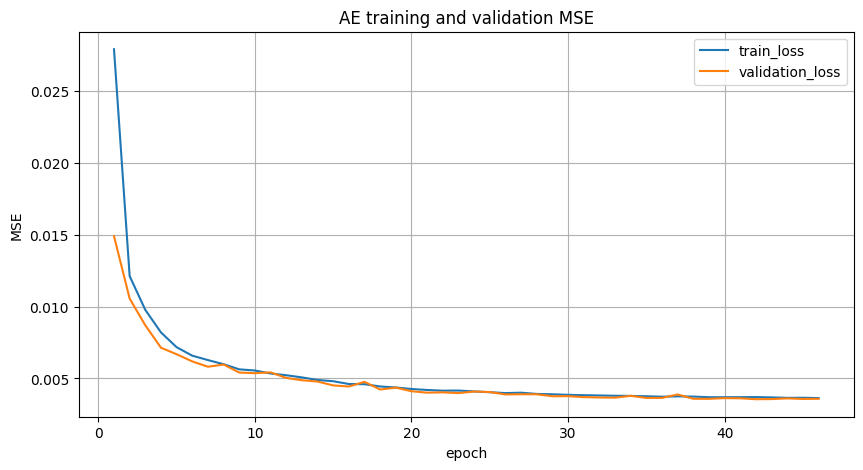

Epochs: 46 | First/final train: 0.0279349 0.00363512 | Best validation: 0.00355497


In [4]:
history=pd.read_csv(PROJECT_ROOT/'results'/'ae_training_history.csv'); display(history.tail())
history.plot(x='epoch',y=['train_loss','validation_loss'],figsize=(10,5),grid=True,title='AE training and validation MSE'); plt.ylabel('MSE'); plt.show()
print('Epochs:',len(history),'| First/final train:',history.train_loss.iloc[0],history.train_loss.iloc[-1],'| Best validation:',history.validation_loss.min())

## 4. Complete test metrics

In [5]:
metrics=json.loads((PROJECT_ROOT/'results'/'ae_test_metrics.json').read_text())
counts={'Overall':metrics['number_of_test_images'],'Authentic':metrics['number_authentic'],'Tampered':metrics['number_tampered']}
display(pd.DataFrame([{'group':name,'count':counts[name],**metrics[key]} for name,key in [('Overall','overall'),('Authentic','authentic'),('Tampered','tampered')]])[['group','count','mse_mean','mse_std','psnr_mean','psnr_std','ssim_mean','ssim_std']])

,group,count,mse_mean,mse_std,psnr_mean,psnr_std,ssim_mean,ssim_std
0,Overall,1892,0.003532,0.002153,25.307680,2.742186,0.761558,0.077744
1,Authentic,1123,0.003422,0.002046,25.443033,2.751612,0.766052,0.077813
2,Tampered,769,0.003694,0.002292,25.110017,2.716273,0.754995,0.077173


## 5. Fresh original vs reconstructed examples

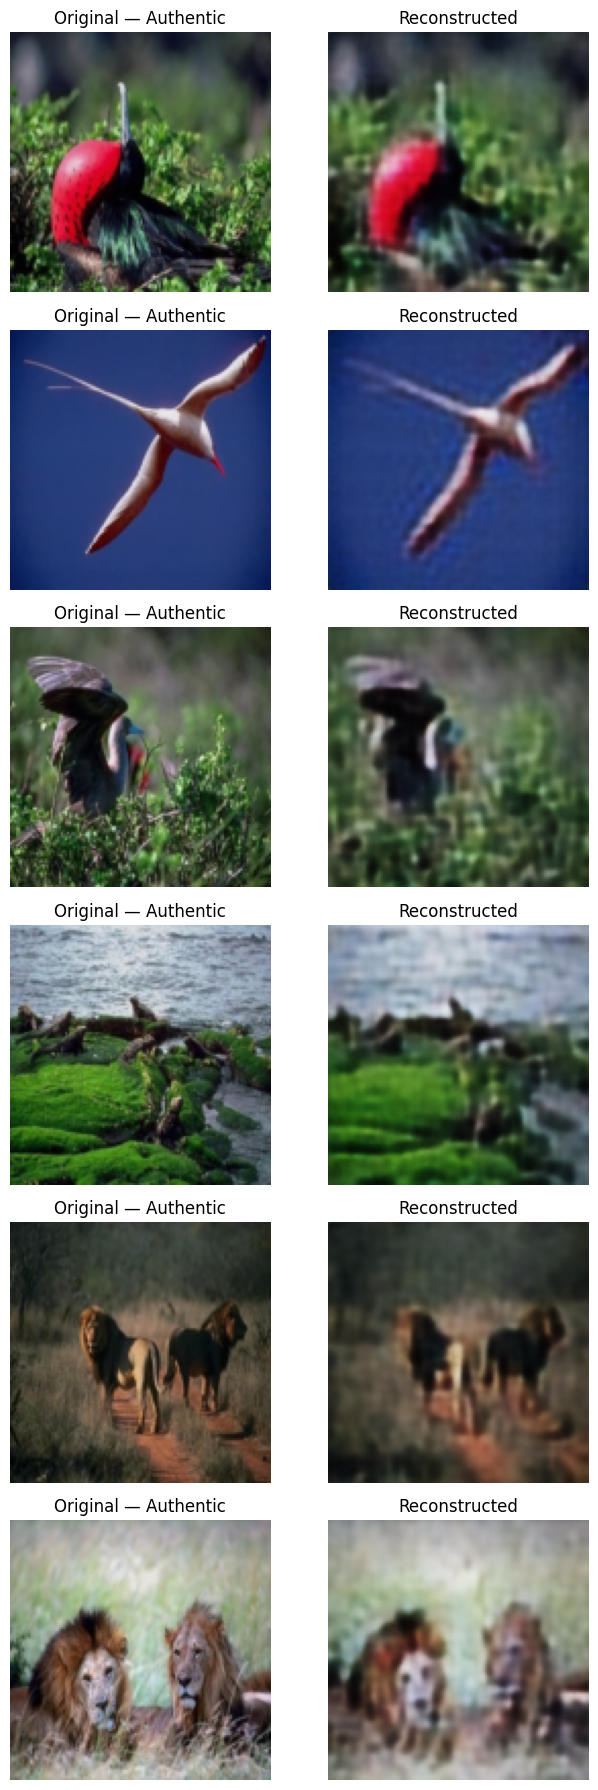

Batch shape: (6, 3, 128, 128) | MSE: 0.002576963510364294


In [6]:
from ae_dataset import AutoencoderImageDataset
from torch.utils.data import DataLoader
batch=next(iter(DataLoader(AutoencoderImageDataset(PROJECT_ROOT/'data'/'splits'/'test.csv',128),batch_size=6,shuffle=False,num_workers=0))); x=batch['image'].to(DEVICE)
with torch.no_grad(): y=model(x)
fig,axes=plt.subplots(6,2,figsize=(7,18))
for i in range(6):
 label='Authentic' if int(batch['label'][i])==0 else 'Tampered'; axes[i,0].imshow(x[i].cpu().permute(1,2,0)); axes[i,0].set_title('Original — '+label); axes[i,1].imshow(y[i].cpu().permute(1,2,0).clamp(0,1)); axes[i,1].set_title('Reconstructed')
 for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show(); print('Batch shape:',tuple(x.shape),'| MSE:',torch.mean((y-x)**2).item())

## 6. Authentic vs tampered exploration

Differences are exploratory and do not make AE a tampering detector.

mse                 psnr                ssim          
                mean       std       mean       std      mean       std
class_name                                                             
authentic   0.003422  0.002047  25.443033  2.752838  0.766052  0.077848
tampered    0.003694  0.002293  25.110017  2.718040  0.754995  0.077224

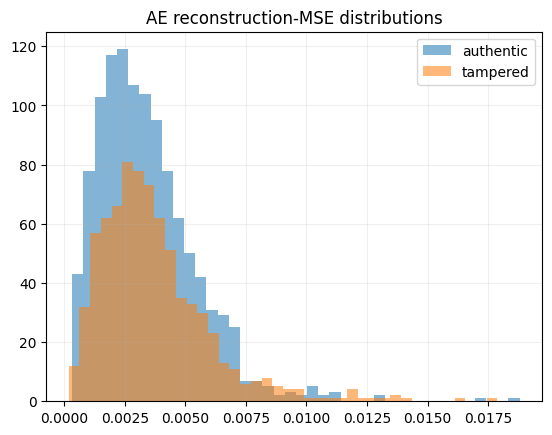

In [7]:
per=pd.read_csv(PROJECT_ROOT/'results'/'ae_test_per_image_metrics.csv'); display(per.groupby('class_name')[['mse','psnr','ssim']].agg(['mean','std']))
for name,g in per.groupby('class_name'): plt.hist(g.mse,bins=40,alpha=.55,label=name)
plt.title('AE reconstruction-MSE distributions'); plt.legend(); plt.grid(alpha=.2); plt.show()

## 7. Denoising AE results

,value
test_images,1892
noise_std,0.1
seed,42
checkpoint_epoch,6
noisy_input,"{'mse': 0.00904314282299813, 'psnr': 20.448555..."
denoised_output,"{'mse': 0.0037564856584409428, 'psnr': 24.9341..."
improvement,"{'mse_reduction_percent': 58.460396656706436, ..."
interpretation_note,"Denoising metrics measure noise removal, not f..."
evaluation_time_seconds,28.883952


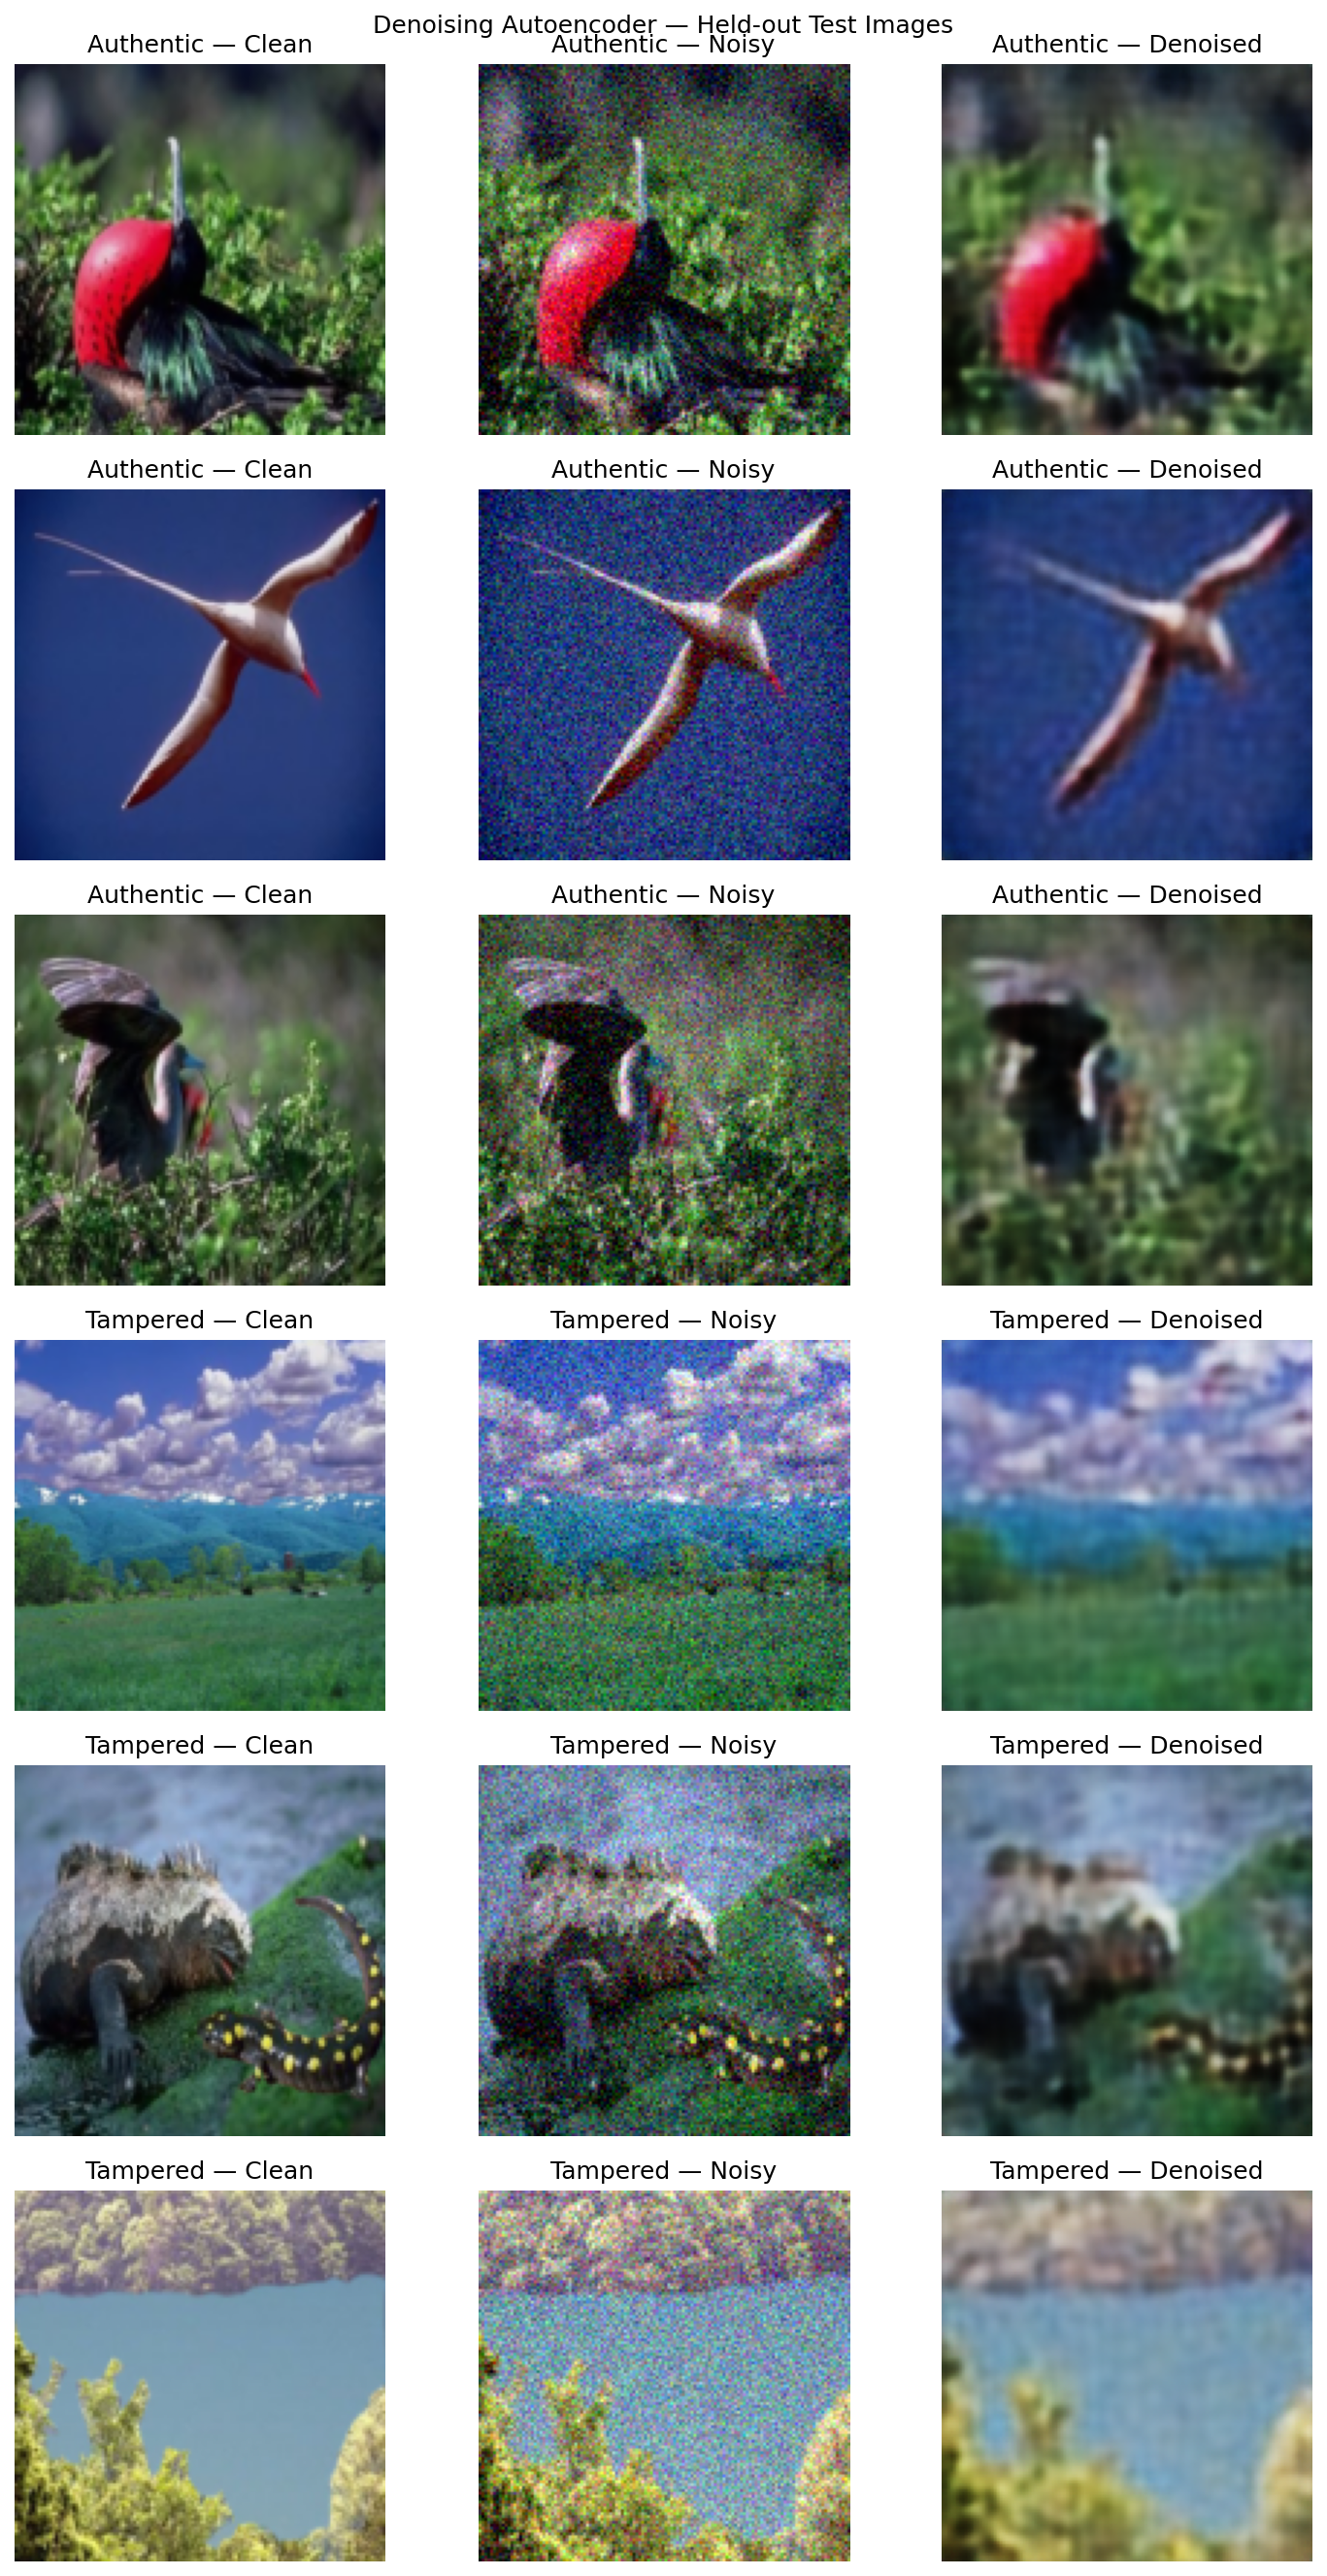

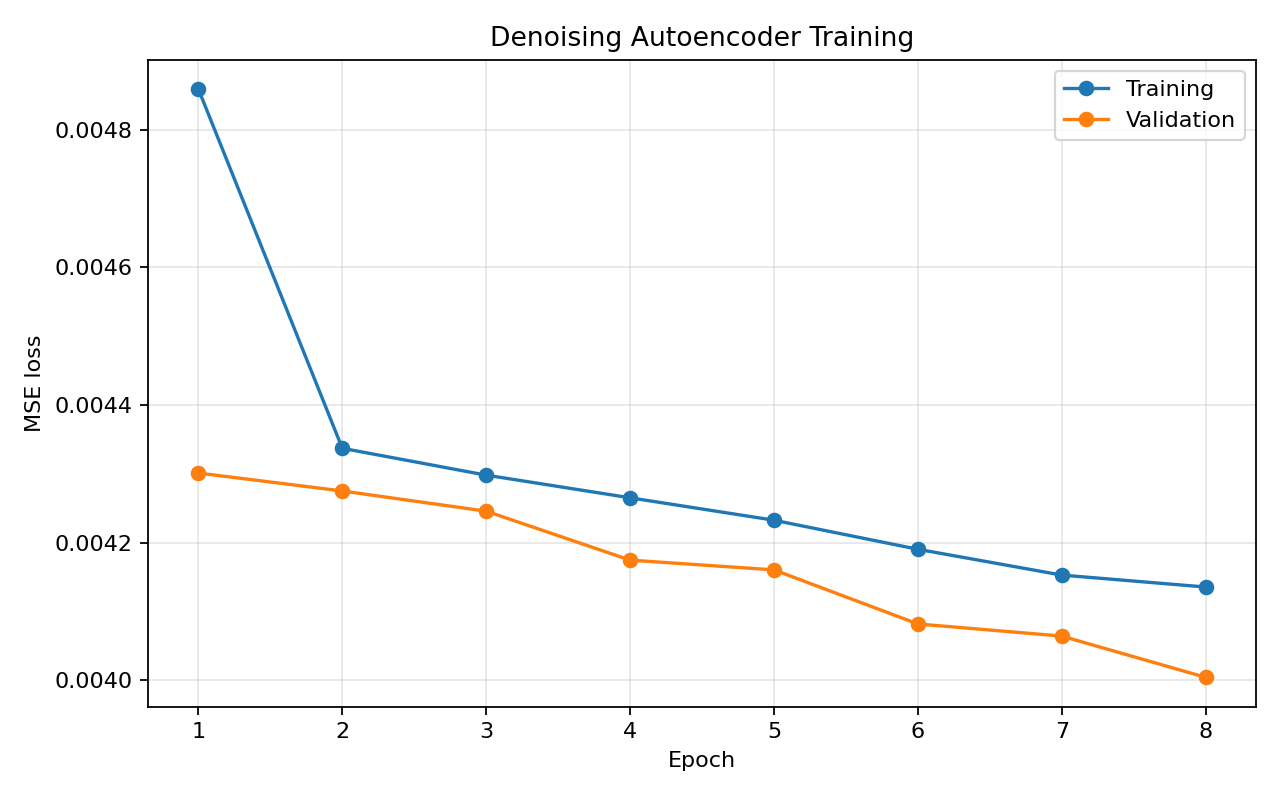

In [8]:
dae=json.loads((PROJECT_ROOT/'results'/'dae_test_metrics.json').read_text()); display(pd.DataFrame([dae]).T.rename(columns={0:'value'}))
for rel in ('outputs/ae/denoising_comparison_grid.png','outputs/ae/dae_training_curve.png'):
 path=PROJECT_ROOT/rel
 if path.is_file(): display(Image.open(path))

## Conclusion

The AE is the deterministic reconstruction and compression module. Its reconstruction statistics are not proof of tampering.